In [1]:
# Part 4: Data Visualization & Machine Learning

In [2]:
# Importing Liabraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing ML liabraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv(r"D:\Richa\BITSOM\Assignments'\2511416_Deshmukh_Richa_Assignment_03\python-assignment-part4\students.csv")

In [4]:
#--- Task 1 - Data Exploration with Pandas

In [5]:
# To print first 5 rows
df.head()

,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [6]:
# To print shape and data types of each column
df.shape

(15, 9)

In [7]:
df.dtypes

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

In [8]:
# To Print Summary statistics for numeric columns
df.describe()

,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [9]:
# To print the count of students who passed and who failed

df['passed'].value_counts()

1    9
0    6
Name: passed, dtype: int64

In [10]:
# 1 means passed and 0 means failed . So 9 students passed and 6 failed.

In [11]:
# to compute and print average score per subject seperately for passing and failing student.

subject_cols = ['math','science','english','history','pe']
# For passed students
df[df['passed']==1][subject_cols].mean()
#for failed students
df[df['passed']==0][subject_cols].mean()

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

In [12]:
# To find and print the student with highest overall average

df['avg_total'] = df[subject_cols].mean(axis=1)
df.loc[df['avg_total'].idxmax()]

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
avg_total               94.0
Name: 3, dtype: object

In [13]:
# --- Task 2 - Data visualization with MatPlotLib

In [14]:
# To add new column avg score to the dataframe
df['avg_score'] = df[subject_cols].mean(axis=1)

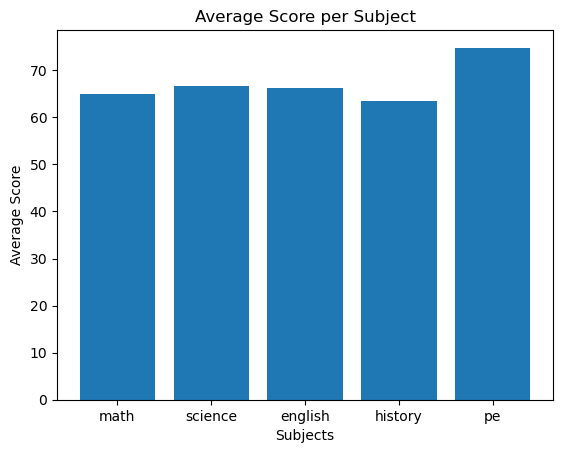

In [15]:
# Bar Chart

avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

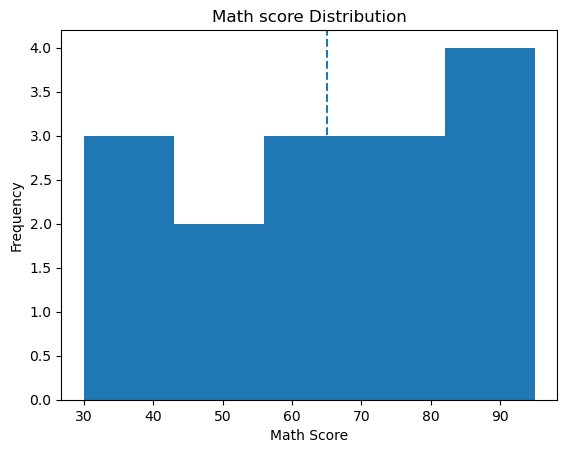

In [16]:
# Histogram

plt.figure()
plt.hist(df["math"], bins=5)

mean_val = df["math"].mean()
plt.axvline(mean_val, linestyle='dashed')
plt.title("Math score Distribution")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.savefig("plot2_hist.png")
plt.show()

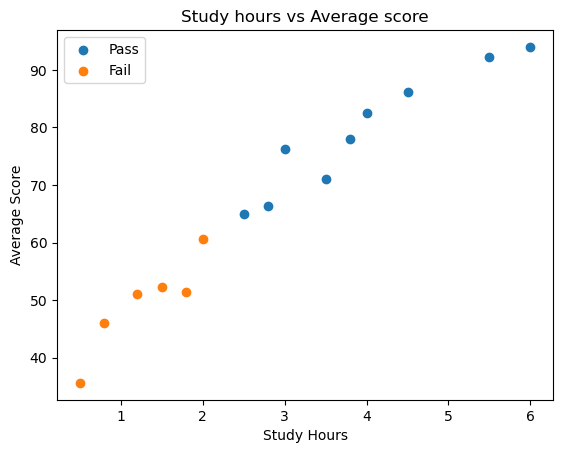

In [17]:
# Scatter Plot

plt.figure()
pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]
plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.xlabel("Study Hours")
plt.ylabel("Average Score")
plt.title("Study hours vs Average score")
plt.legend()
plt.savefig("plot3_Scatter.png")
plt.show()

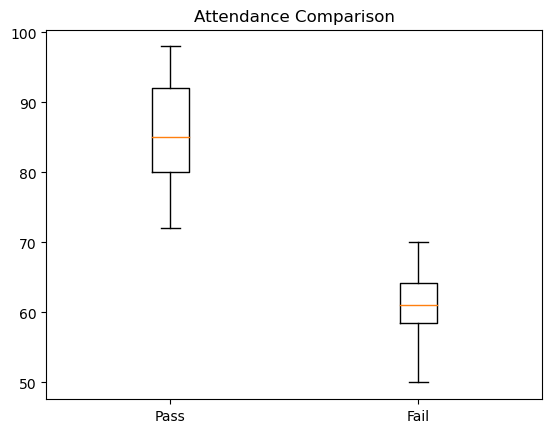

In [18]:
# Box Plot

pass_att = df[df['passed'] == 1]['attendance_pct']
fail_att = df[df['passed'] == 0]['attendance_pct']

plt.figure()
plt.boxplot([pass_att,fail_att], labels=['Pass','Fail'])
plt.title("Attendance Comparison")
plt.savefig("plot4_Box.png")
plt.show()

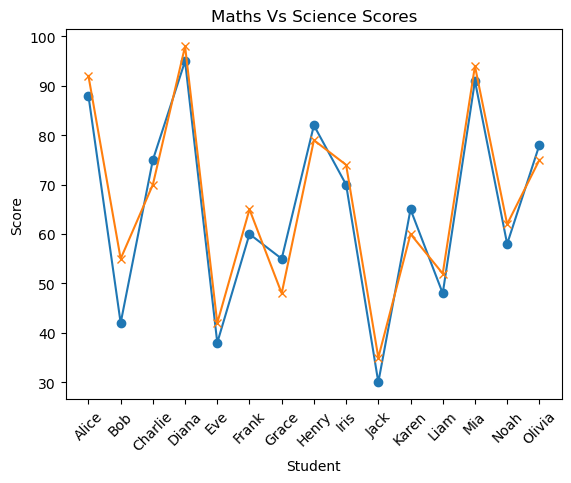

In [21]:
# Line Plot

plt.figure()

plt.plot(df["name"], df["math"], marker="o", label="Math")
plt.plot(df["name"], df["science"], marker="x", label="Science")

plt.xticks(rotation=45)
plt.xlabel("Student")
plt.ylabel("Score")
plt.title("Maths Vs Science Scores")
plt.savefig("plot5_Line.png")
plt.show()

In [ ]:
#--- Task 3 - Data Visualization with Seaborn

In [ ]:
# Box Plot using Seaborn Library
fig, (ax1, ax2) = plt.subplots(1, 2)

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Math Scores")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Science Scores")

plt.savefig("plot6_seaborn_bar.png")
plt.show()

In [ ]:
# Scatter plot using Seaborn Library

plt.figure()

sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score')

plt.title("Attendance vs Performance")
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [ ]:
# MatPlotLib Vs Seaborn Library

# Seaborn needs less coding where as MatPlotLib needs more manual custumization
# In Seaborn, plotting is easier and cleaner whereas MatPloLib needs fine control over every detail
# Seaborn is attractive by default wheras MatplotLib needs customization

In [ ]:
#----Task 4 --- Machine Learnig with scikit-learn

In [ ]:
# Step 1 - To Prepare Data
# To seperate data into features(x) and target(y)
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

# To split into train(80%) and test(20%)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# to Scale features using StandardScaler — fit on training data only, then transform both sets

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Step 2 - Train a Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)

In [ ]:
# Step 3 - Evaluate the model

y_pred = model.predict(X_test_scaled)

test_accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_accuracy)

# To print names of students with their actual label and predicted label
names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(names, y_test, y_pred):
    status = "✅" if actual == pred else "❌"
    print(name, "Actual:", actual, "Pred:", pred, status)

In [ ]:
# Step 4 - Feature Importance

coeffs = model.coef_[0]

feature_importance = list(zip(X.columns, coeffs))
feature_importance.sort(key= lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
for f in feature_importance:
    print(f)

In [ ]:
# To create horizontal bar chart showing all coefficient using MatPlotLib
features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

plt.figure()
plt.barh(features, values)
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.savefig("feature_importance.png")
plt.show()

In [ ]:
# Step 5 - Predict for a new student

new_student = [[75, 70, 68, 65, 80, 82, 3.2]]

# Scaling the data
new_scaled = scaler.transform(new_student)

prediction = model.predict(new_scaled)
prob = model.predict_proba(new_scaled)

print("\nNew Student prediction:", "Pass" if prediction == 1 else "Fail")
print("Probability:", prob)